# 02 · Comprensión de los Datos
### EDA Estadístico Completo — Indian Road Accident Dataset
---
Este notebook es un análisis exploratorio completo sobre un dataset de accidentes de tráfico en carreteras de India. Su objetivo es conocer bien los datos antes de construir cualquier modelo.

In [1]:
import sys, os
ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import (skew, kurtosis, normaltest, kstest,
                          chi2_contingency, jarque_bera,
                          norm, uniform, expon, gamma)
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import DataLoader

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})
COLORS  = ['#4C9BE8', '#F0A500', '#E05A5A']
PALETTE = {'minor': '#4C9BE8', 'major': '#F0A500', 'fatal': '#E05A5A'}

FIGURES = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(FIGURES, exist_ok=True)

def guardar(nombre):
    plt.savefig(os.path.join(FIGURES, nombre), dpi=110, bbox_inches='tight')

loader = DataLoader(os.path.join(ROOT, 'data', 'indian_roads_dataset.csv'))
df     = loader.cargar_datos()

NUM_VARS = ['hour', 'temperature', 'lanes', 'vehicles_involved', 'casualties', 'risk_score']
CAT_VARS = ['road_type', 'weather', 'visibility', 'traffic_density', 'cause', 'day_of_week']


---
## Diccionario de variables

In [2]:
diccionario = pd.DataFrame([
    # Identificadores
    ('accident_id',       'object',  'Identificador',       'ID único del accidente — no predictivo'),
    ('date',              'object',  'Fecha (str)',         'Fecha del accidente'),
    ('city',              'object',  'Categórica nominal',  'Ciudad del accidente'),
    ('state',             'object',  'Categórica nominal',  'Estado del accidente'),
    # Variables temporales
    ('hour',              'int64',   'Numérica discreta',   'Hora del día (0–23)'),
    ('day_of_week',       'object',  'Categórica nominal',  'Día de la semana'),
    ('is_weekend',        'int64',   'Binaria',             '1 si es fin de semana'),
    ('is_peak_hour',      'int64',   'Binaria',             '1 si es hora pico (7–9h o 17–19h)'),
    # Variables de la vía
    ('road_type',         'object',  'Categórica nominal',  'Tipo de vía: highway / urban / rural'),
    ('lanes',             'int64',   'Numérica discreta',   'Número de carriles'),
    ('traffic_signal',    'int64',   'Binaria',             '1 si hay semáforo en el lugar'),
    # Variables ambientales
    ('weather',           'object',  'Categórica nominal',  'Condición climática: clear / fog / rain'),
    ('visibility',        'object',  'Categórica ordinal',  'Visibilidad: high / medium / low'),
    ('temperature',       'float64', 'Numérica continua',   'Temperatura en °C'),
    # Variables de tráfico
    ('traffic_density',   'object',  'Categórica ordinal',  'Densidad de tráfico: low / medium / high'),
    # Variables del accidente
    ('cause',             'object',  'Categórica nominal',  'Causa del accidente'),
    ('vehicles_involved', 'int64',   'Numérica discreta',   'Vehículos involucrados'),
    ('casualties',        'int64',   'Numérica discreta',   'Número de víctimas / afectados'),
    ('festival',          'object',  'Categórica nominal',  'Festival activo (99.4% nulos → sin festival)'),
    # Indicador de riesgo
    ('risk_score',        'float64', 'Numérica continua',   'Indicador de riesgo vial [0.1–1.0] — del CSV'),
    # Variable objetivo
    ('accident_severity', 'object',  'Target multiclase',   'Severidad: minor / major / fatal'),
], columns=['Variable', 'Tipo pandas', 'Clasificación', 'Descripción'])

diccionario


,Variable,Tipo pandas,Clasificación,Descripción
0,accident_id,object,Identificador,ID único del accidente — no predictivo
1,date,object,Fecha (str),Fecha del accidente
2,city,object,Categórica nominal,Ciudad del accidente
3,state,object,Categórica nominal,Estado del accidente
4,hour,int64,Numérica discreta,Hora del día (0–23)
5,day_of_week,object,Categórica nominal,Día de la semana
6,is_weekend,int64,Binaria,1 si es fin de semana
7,is_peak_hour,int64,Binaria,1 si es hora pico (7–9h o 17–19h)
8,road_type,object,Categórica nominal,Tipo de vía: highway / urban / rural
9,lanes,int64,Numérica discreta,Número de carriles


Se crea una tabla que describe cada columna del dataset: qué tipo de dato es, su clasificación y una breve descripción.

### Clasificación de variables por tipo

In [3]:
resumen_tipos = pd.DataFrame({
    'Tipo': [
        'Numéricas continuas', 'Numéricas discretas',
        'Categóricas nominales', 'Categóricas ordinales',
        'Binarias', 'Identificadores / Fechas', 'Variable objetivo'
    ],
    'Cantidad': [2, 4, 5, 2, 3, 3, 1],
    'Ejemplos': [
        'temperature, risk_score',
        'hour, lanes, vehicles_involved, casualties',
        'road_type, weather, cause, city, day_of_week',
        'visibility, traffic_density',
        'is_weekend, is_peak_hour, traffic_signal',
        'accident_id, date, state',
        'accident_severity'
    ]
})
resumen_tipos


,Tipo,Cantidad,Ejemplos
0,Numéricas continuas,2,"temperature, risk_score"
1,Numéricas discretas,4,"hour, lanes, vehicles_involved, casualties"
2,Categóricas nominales,5,"road_type, weather, cause, city, day_of_week"
3,Categóricas ordinales,2,"visibility, traffic_density"
4,Binarias,3,"is_weekend, is_peak_hour, traffic_signal"
5,Identificadores / Fechas,3,"accident_id, date, state"
6,Variable objetivo,1,accident_severity


 Las variables se agrupan en:

- Numéricas (hora, temperatura, carriles, vehículos, víctimas, puntaje de riesgo)
- Categóricas (tipo de vía, clima, visibilidad, densidad de tráfico, causa, día de la semana)
- Binarias (¿es fin de semana? ¿es hora pico? ¿hay semáforo?)
- Variable objetivo: accident_severity que puede ser leve, grave o fatal

---
## 2.1 Estructura del dataset y calidad básica

In [4]:
df.head()


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [6]:
display(pd.DataFrame({
    'Métrica': ['Total registros', 'Total variables', 'Duplicados exactos', 'IDs únicos'],
    'Valor':   [f'{df.shape[0]:,}', df.shape[1],
                df.duplicated().sum(), df['accident_id'].nunique()]
}).style.set_caption('Calidad básica del dataset').hide(axis='index'))


Métrica,Valor
Total registros,"20,000"
Total variables,24
Duplicados exactos,0
IDs únicos,20000


Se revisa cuántos registros tiene el dataset, cuántas columnas, si hay filas duplicadas y si los IDs son únicos. 

---
## 2.2 Análisis de valores nulos

In [7]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
df_nulos = (pd.DataFrame({'Nulos': nulos, '% Nulos': pct})
              .query('Nulos > 0')
              .sort_values('% Nulos', ascending=False))
display(df_nulos.style.set_caption('Variables con valores nulos')
        .background_gradient(cmap='YlOrRd', subset=['% Nulos']))


,Nulos,% Nulos
festival,19885,99.420000


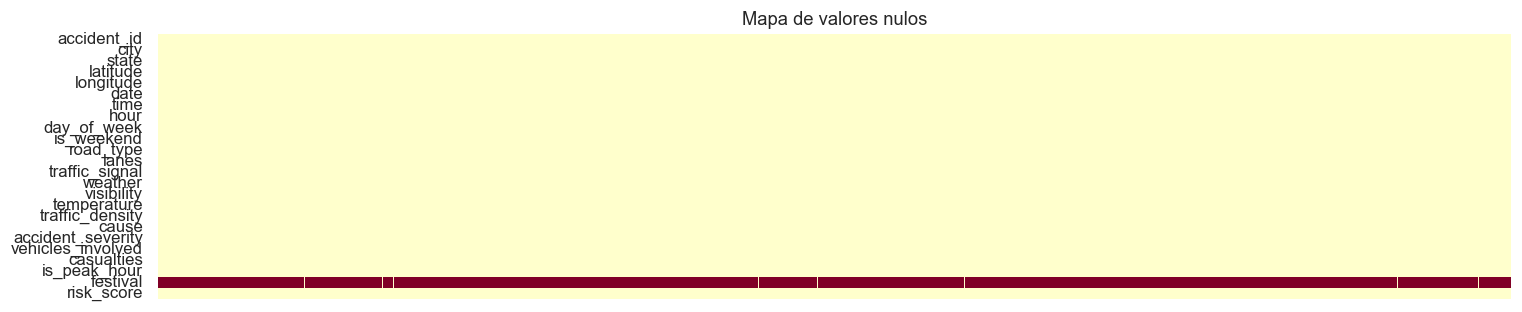

In [8]:
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(df.isnull().T, cbar=False, cmap='YlOrRd',
            yticklabels=True, xticklabels=False, ax=ax)
ax.set_title('Mapa de valores nulos')
plt.tight_layout()
guardar('mapa_nulos.png')
plt.show()


Se detecta qué columnas tienen datos faltantes. El hallazgo principal es que festival tiene 99.4% de valores nulos, pero esto no es un error: simplemente significa que casi todos los accidentes ocurrieron en días sin festival. La decisión es imputar esos nulos con la categoría `none`.

---
## 2.3 Variable objetivo — `accident_severity`

In [9]:
conteo = df['accident_severity'].value_counts()
pct    = df['accident_severity'].value_counts(normalize=True).mul(100).round(2)
ratio  = conteo.max() / conteo.min()

display(pd.DataFrame({
    'Clase': conteo.index,
    'Conteo': conteo.values,
    'Porcentaje (%)': pct.values,
    'Descripción': ['Daños leves / materiales', 'Lesiones graves',  'Víctimas mortales']
}).style.set_caption(f'Distribución del target — Ratio de desbalance: {ratio:.1f}x → Usar class_weight="balanced"')
  .hide(axis='index'))


Clase,Conteo,Porcentaje (%),Descripción
minor,11025,55.120000,Daños leves / materiales
major,5988,29.940000,Lesiones graves
fatal,2987,14.940000,Víctimas mortales


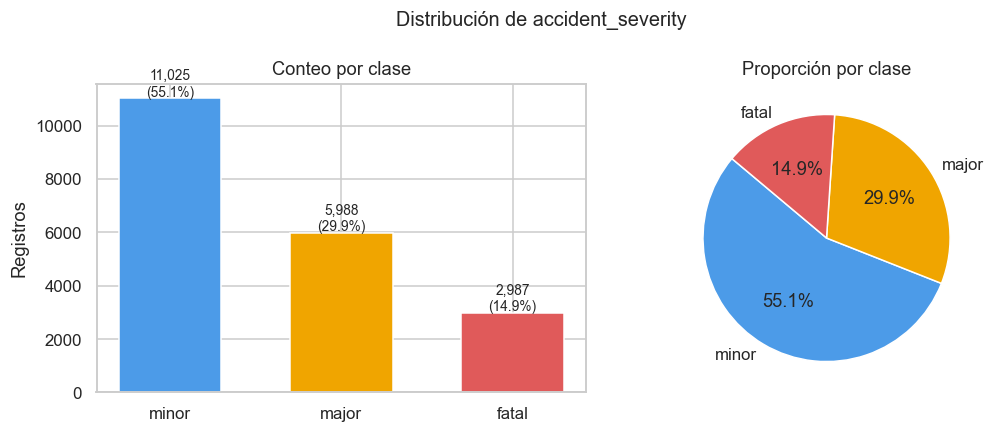

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bars = axes[0].bar(conteo.index, conteo.values, color=COLORS, edgecolor='white', width=0.6)
axes[0].set_title('Conteo por clase'); axes[0].set_ylabel('Registros')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+80,
                 f'{h:,}\n({h/len(df)*100:.1f}%)', ha='center', fontsize=9)
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=COLORS, startangle=140, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporción por clase')
plt.suptitle('Distribución de accident_severity', fontsize=13)
plt.tight_layout()
guardar('distribucion_target.png')
plt.show()


Se analiza cuántos accidentes hay de cada tipo (leve, grave, fatal), identificando que las clases están algo desbalanceadas, ya que los accidentes fatales representan una menor proporción frente a los no fatales. Este comportamiento se puede cuantificar mediante el ratio de desbalance, donde se observa que por cada accidente fatal existen varios no fatales, lo que indica un desbalance moderado en el dataset.

Debido a esto, se decidió usar class_weight = 'balanced' al entrenar el modelo, con el fin de compensar la menor representación de la clase minoritaria y evitar que el modelo se sesgue hacia la clase mayoritaria.

---
## 2.4 Estadísticas descriptivas — Variables numéricas
### Media · Mediana · Moda · Dispersión · Forma

In [11]:
rows = []
for c in NUM_VARS:
    media   = df[c].mean()
    mediana = df[c].median()
    moda    = df[c].mode()[0]
    std     = df[c].std()
    cv      = std / media * 100
    q1, q3  = df[c].quantile([0.25, 0.75])
    iqr     = q3 - q1
    sk      = skew(df[c])
    kurt    = kurtosis(df[c])
    if abs(sk) < 0.5:
        forma = 'Simétrica'
    elif sk > 0:
        forma = 'Sesgo derecho'
    else:
        forma = 'Sesgo izquierdo'
    rows.append({'Variable':c, 'Media':round(media,3), 'Mediana':round(mediana,3),
                 'Moda':round(moda,3), 'Std':round(std,3), 'CV%':round(cv,1),
                 'IQR':round(iqr,3), 'Skewness':round(sk,4),
                 'Kurtosis':round(kurt,4), 'Forma':forma})

display(pd.DataFrame(rows).style
        .set_caption('Medidas de tendencia central, posición y dispersión')
        .background_gradient(cmap='RdYlGn_r', subset=['Skewness'])
        .hide(axis='index'))


Variable,Media,Mediana,Moda,Std,CV%,IQR,Skewness,Kurtosis,Forma
hour,11.487000,12.000000,2.000000,6.946000,60.500000,13.000000,-0.002900,-1.210400,Simétrica
temperature,27.580000,28.000000,22.000000,7.455000,27.000000,13.000000,-0.009800,-1.193100,Simétrica
lanes,3.494000,4.000000,4.000000,1.705000,48.800000,3.000000,-0.004100,-1.263500,Simétrica
vehicles_involved,2.992000,3.000000,1.000000,1.416000,47.300000,2.000000,0.010600,-1.301200,Simétrica
casualties,1.726000,1.000000,1.000000,1.489000,86.300000,2.000000,0.621800,-0.593400,Sesgo derecho
risk_score,0.438000,0.450000,0.450000,0.218000,49.800000,0.350000,0.131800,-0.597400,Simétrica


Para cada variable numérica se calculan: media, mediana, moda, desviación estándar, coeficiente de variación, rango intercuartílico, asimetría (skewness) y kurtosis.
 Los hallazgos clave son:
casualties (víctimas) tiene sesgo positivo, la mayoría de accidentes tiene pocas víctimas, pero algunos tienen muchas. Tambien se identifico que ninguna variable tiene asimetría mayor a 1, lo que significa que no hacen falta transformaciones matemáticas.

### Estadísticas descriptivas completas

In [12]:
df[NUM_VARS].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
hour,20000.0,11.487,6.946,0.0,5.00,12.00,18.0,23.0
temperature,20000.0,27.580,7.455,15.0,21.00,28.00,34.0,40.0
lanes,20000.0,3.494,1.705,1.0,2.00,4.00,5.0,6.0
vehicles_involved,20000.0,2.992,1.416,1.0,2.00,3.00,4.0,5.0
casualties,20000.0,1.726,1.489,0.0,1.00,1.00,3.0,5.0
risk_score,20000.0,0.438,0.218,0.1,0.25,0.45,0.6,1.0


---
## 2.5 Variables categóricas — Moda, frecuencia y entropía

In [13]:
rows_cat = []
for c in CAT_VARS:
    frec     = df[c].value_counts()
    moda     = frec.index[0]
    n_moda   = frec.iloc[0]
    pct_moda = round(n_moda / len(df) * 100, 1)
    n_cats   = df[c].nunique()
    entropia = round(stats.entropy(frec / len(df), base=2), 3)
    max_ent  = round(np.log2(n_cats), 3)
    balance  = 'Uniforme ' if entropia/max_ent > 0.95 else 'Concentrada '
    rows_cat.append({'Variable':c, 'Moda':moda, 'Frec. moda':n_moda,
                     '% moda':pct_moda, 'N° categorías':n_cats,
                     'Entropía':entropia, 'Entropía máx':max_ent, 'Balance':balance})

display(pd.DataFrame(rows_cat).style
        .set_caption('Variables cualitativas — Moda, frecuencia y entropía')
        .background_gradient(cmap='Blues', subset=['Entropía'])
        .hide(axis='index'))


Variable,Moda,Frec. moda,% moda,N° categorías,Entropía,Entropía máx,Balance
road_type,urban,6745,33.700000,3,1.585000,1.585000,Uniforme
weather,clear,6690,33.400000,3,1.585000,1.585000,Uniforme
visibility,low,9987,49.900000,3,1.459000,1.585000,Concentrada
traffic_density,low,7067,35.300000,3,1.580000,1.585000,Uniforme
cause,distraction,4026,20.100000,5,2.322000,2.322000,Uniforme
day_of_week,Monday,2966,14.800000,7,2.807000,2.807000,Uniforme


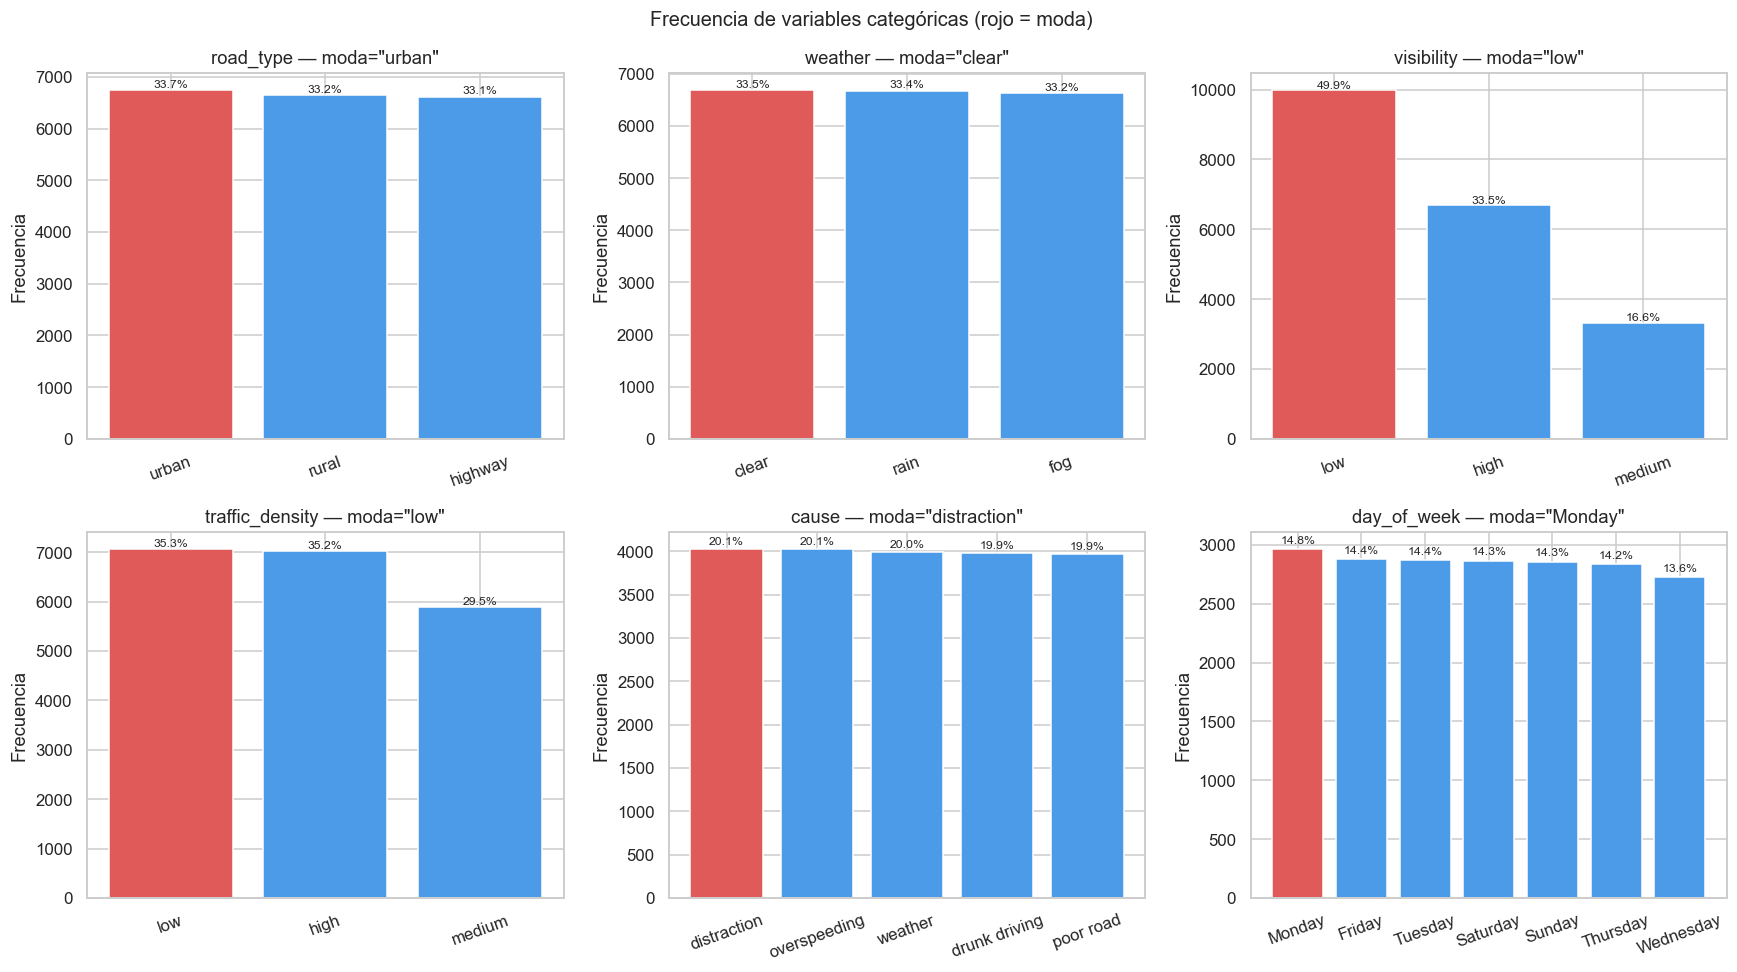

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, var in enumerate(CAT_VARS):
    frec   = df[var].value_counts()
    cols_b = ['#E05A5A' if j==0 else '#4C9BE8' for j in range(len(frec))]
    axes[i].bar(frec.index, frec.values, color=cols_b, edgecolor='white')
    axes[i].set_title(f'{var} — moda="{frec.index[0]}"')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=20)
    for j, v in enumerate(frec.values):
        axes[i].text(j, v+50, f'{v/len(df)*100:.1f}%', ha='center', fontsize=8)
plt.suptitle('Frecuencia de variables categóricas (rojo = moda)', fontsize=13)
plt.tight_layout()
guardar('frecuencia_categoricas.png')
plt.show()


Se analiza la distribución de cada variable categórica: cuál es la categoría más frecuente, cuántas categorías distintas hay, y qué tan uniforme es la distribución, usando entropía. Se generan gráficas de barras para ver visualmente cuáles valores predominan.

---
## 2.6 Detección de outliers — IQR y Z-Score

In [15]:
rows_out = []
for c in NUM_VARS:
    Q1, Q3  = df[c].quantile([0.25, 0.75])
    IQR     = Q3 - Q1
    out_iqr = int(((df[c] < Q1-1.5*IQR) | (df[c] > Q3+1.5*IQR)).sum())
    out_z   = int((np.abs(stats.zscore(df[c])) > 3).sum())
    rows_out.append({'Variable':c, 'Q1':round(Q1,3), 'Q3':round(Q3,3),
                     'IQR':round(IQR,3), 'Outliers IQR':out_iqr,
                     'Outliers Z-Score':out_z,
                     '% del total':round(out_iqr/len(df)*100,1),
                     'Decisión':'Sin acción ' if out_iqr==0 else 'Revisar '})

display(pd.DataFrame(rows_out).style
        .set_caption('Detección de outliers — IQR (1.5×IQR) y Z-Score (|z|>3)')
        .hide(axis='index'))


Variable,Q1,Q3,IQR,Outliers IQR,Outliers Z-Score,% del total,Decisión
hour,5.000000,18.000000,13.000000,0,0,0.000000,Sin acción
temperature,21.000000,34.000000,13.000000,0,0,0.000000,Sin acción
lanes,2.000000,5.000000,3.000000,0,0,0.000000,Sin acción
vehicles_involved,2.000000,4.000000,2.000000,0,0,0.000000,Sin acción
casualties,1.000000,3.000000,2.000000,0,0,0.000000,Sin acción
risk_score,0.250000,0.600000,0.350000,0,0,0.000000,Sin acción


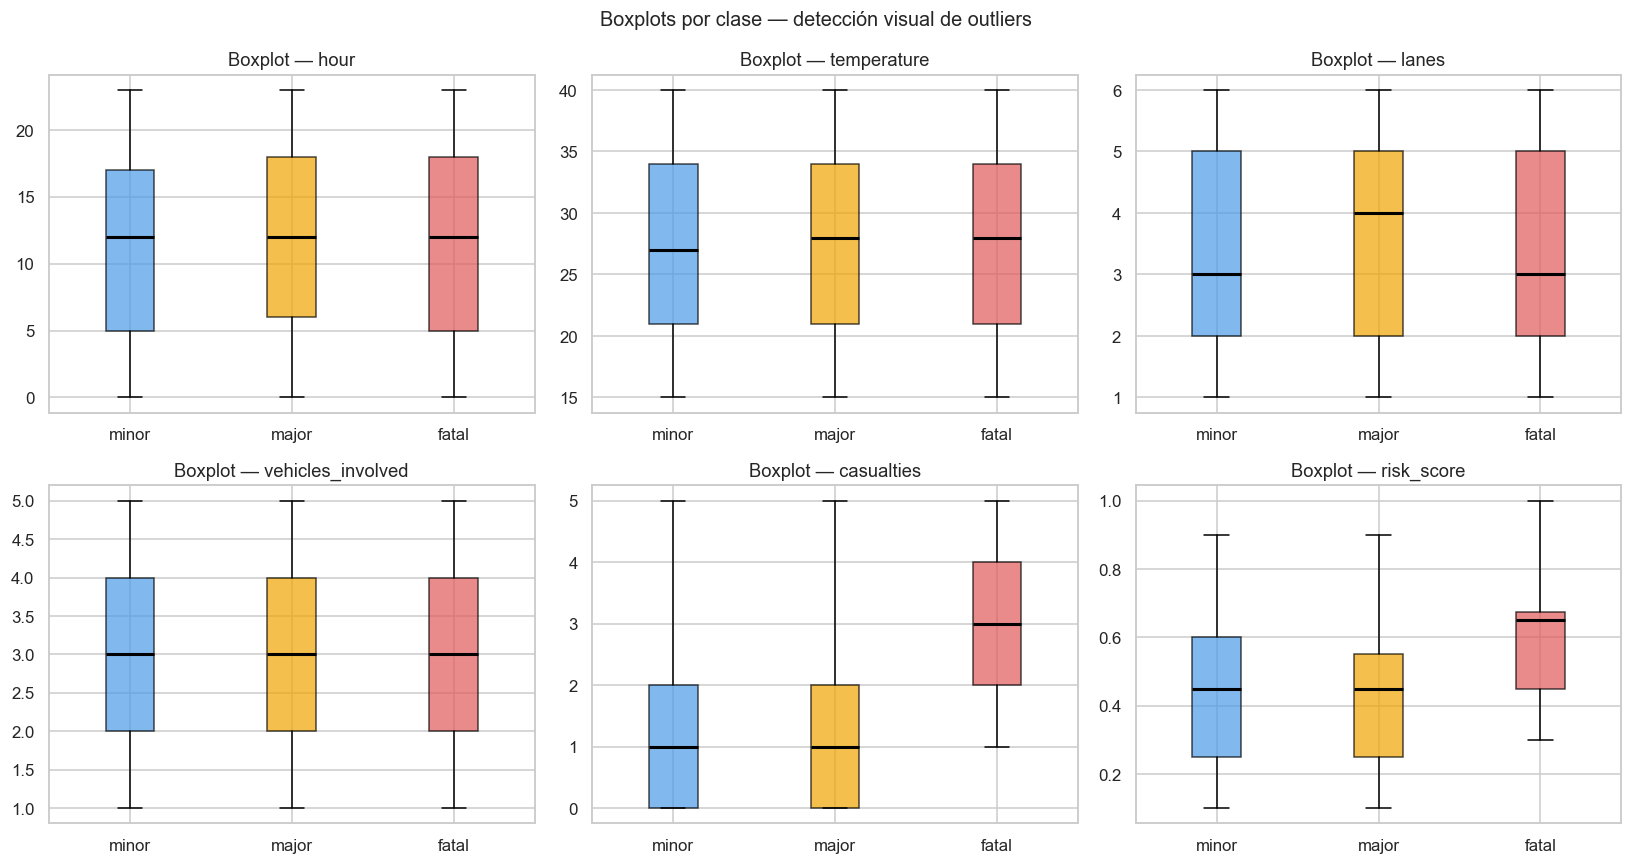

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, var in enumerate(NUM_VARS):
    data_box = [df[df['accident_severity']==c][var].dropna().values
                for c in ['minor','major','fatal']]
    bp = axes[i].boxplot(data_box, labels=['minor','major','fatal'],
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[i].set_title(f'Boxplot — {var}')
plt.suptitle('Boxplots por clase — detección visual de outliers', fontsize=13)
plt.tight_layout()
guardar('boxplots_numericas.png')
plt.show()


Se usan dos métodos clásicos para buscar datos atipicos o extremos:

IQR (rango intercuartílico): Se encontraron valores muy por encima o por debajo del rango normal.
Z-Score: valores a más de 3 desviaciones estándar de la media.

Como resultado se obtuvo 0 outliers en todas las variables. Esto es una de las razones que confirma que  dataset es sintético. Por lo tanto no se elimina ningún registro.

---
## 2.7 Pruebas de normalidad — Tres métodos

In [17]:
rows_norm = []
for c in NUM_VARS:
    data     = df[c].values
    _, p_dag = normaltest(data)
    _, p_ks  = kstest((data-data.mean())/data.std(), 'norm')
    _, p_jb  = jarque_bera(data)
    concl    = 'NO normal ' if all(p < 0.05 for p in [p_dag, p_ks, p_jb]) else 'Normal '
    rows_norm.append({'Variable':c,
                      "D'Agostino p":round(p_dag,6),
                      'KS p':round(p_ks,6),
                      'Jarque-Bera p':round(p_jb,6),
                      'Conclusión':concl})

display(pd.DataFrame(rows_norm).style
        .set_caption('Pruebas de normalidad — Árbol, RF y Gradient Boosting NO requieren normalidad')
        .hide(axis='index'))


Variable,D'Agostino p,KS p,Jarque-Bera p,Conclusión
hour,0.000000,0.000000,0.000000,NO normal
temperature,0.000000,0.000000,0.000000,NO normal
lanes,0.000000,0.000000,0.000000,NO normal
vehicles_involved,0.000000,0.000000,0.000000,NO normal
casualties,0.000000,0.000000,0.000000,NO normal
risk_score,0.000000,0.000000,0.000000,NO normal


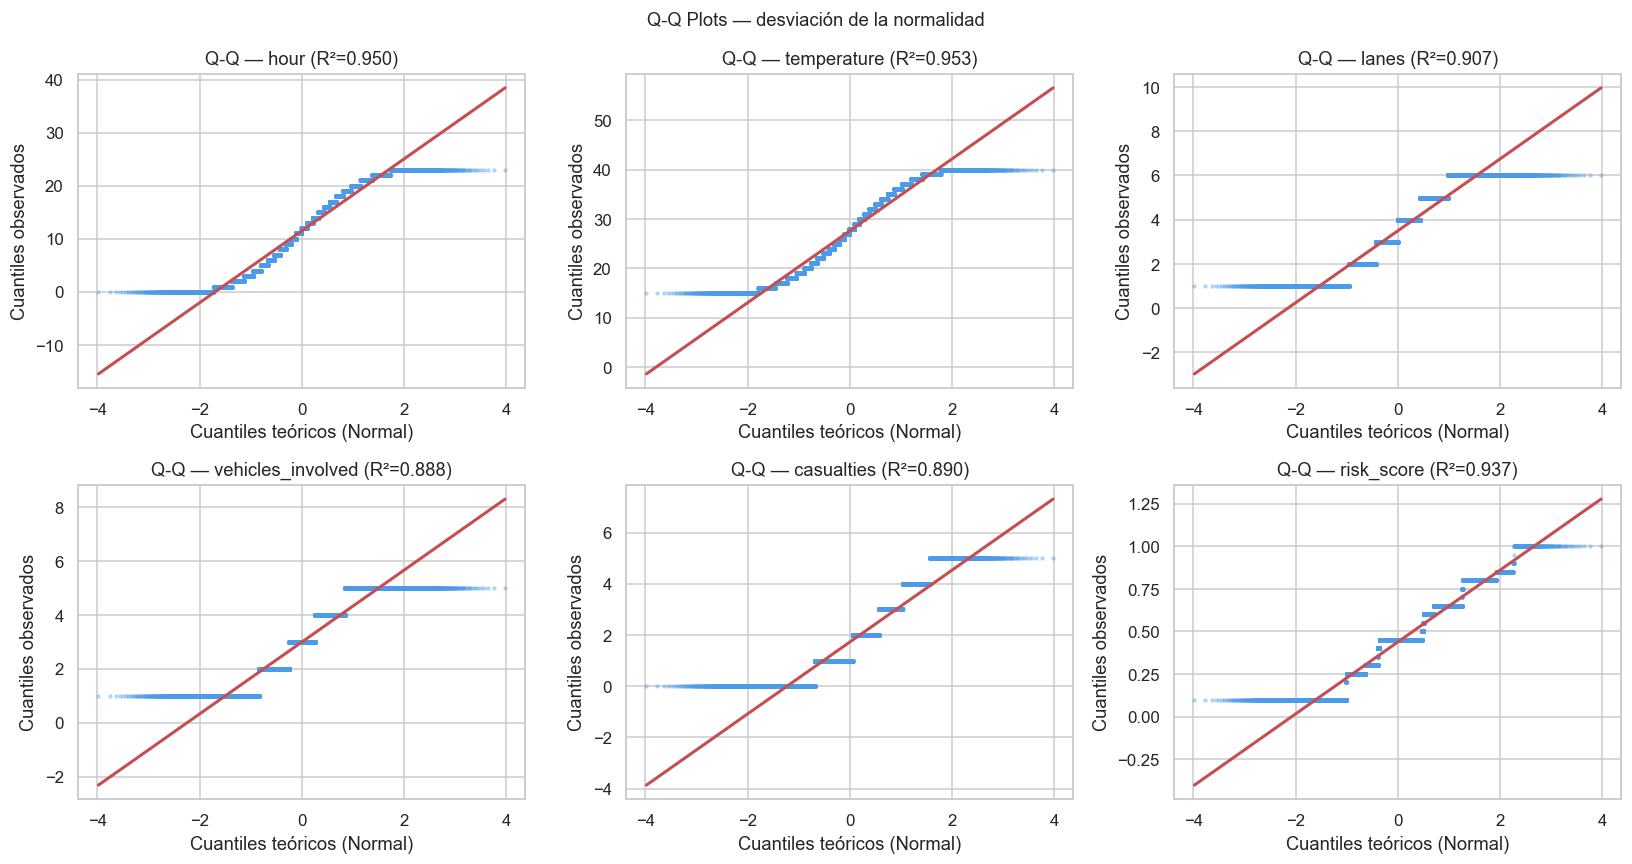

In [18]:
# Q-Q plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, var in enumerate(NUM_VARS):
    data = df[var].values
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    axes[i].plot(osm, osr, 'o', color=COLORS[0], alpha=0.3, markersize=2)
    axes[i].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
    axes[i].set_title(f'Q-Q — {var} (R²={r**2:.3f})')
    axes[i].set_xlabel('Cuantiles teóricos (Normal)')
    axes[i].set_ylabel('Cuantiles observados')
plt.suptitle('Q-Q Plots — desviación de la normalidad', fontsize=12)
plt.tight_layout()
guardar('qq_plots.png')
plt.show()


Se aplican tres pruebas estadísticas para ver si las variables siguen una distribución normal:

D'Agostino
Kolmogorov-Smirnov
Jarque-Bera

Ninguna variable es normal. Pero esto no genera problema porque los modelos que se van a usar (árboles, Random Forest, Gradient Boosting) no requieren normalidad.

---
## 2.8 Ajuste de distribuciones por AIC

In [19]:
distribuciones = {'Normal': norm, 'Uniforme': uniform,
                  'Exponencial': expon, 'Gamma': gamma}
rows_aic = []
for c in NUM_VARS:
    data = df[c].values
    aics = {}
    for nombre, dist in distribuciones.items():
        try:
            params  = dist.fit(data)
            log_lik = dist.logpdf(data, *params).sum()
            aics[nombre] = round(2*len(params) - 2*log_lik, 1)
        except:
            aics[nombre] = float('inf')
    mejor = min(aics, key=aics.get)
    row   = {'Variable': c}
    row.update({k: (' '+str(v) if k==mejor else v) for k, v in aics.items()})
    row['Mejor ajuste'] = mejor
    rows_aic.append(row)

display(pd.DataFrame(rows_aic).style
        .set_caption('Ajuste de distribuciones por AIC — menor AIC = mejor ajuste')
        .hide(axis='index'))


Variable,Normal,Uniforme,Exponencial,Gamma,Mejor ajuste
hour,134284.700000,125423.8,137653.300000,134286.700000,Uniforme
temperature,137114.600000,128759.0,141287.100000,137117.200000,Uniforme
lanes,78112.700000,64381.5,76558.700000,78114.800000,Uniforme
vehicles_involved,70660.800000,55455.8,67569.600000,70662.100000,Uniforme
casualties,72687.500000,64381.500000,61846.700000,-274998.3,Gamma
risk_score,-4146.100000,-4210.400000,-3433.500000,-4253.3,Gamma


Se comparan cuatro distribuciones posibles (Normal, Uniforme, Exponencial, Gamma) usando el criterio AIC (mientras más bajo, mejor ajuste). Esto permite entender la forma de los datos, aunque no cambia las decisiones de preprocesamiento.

---
## 2.9 Evaluación de transformaciones

In [20]:
rows_t = []
for c in NUM_VARS:
    data    = df[c].values
    sk_orig = abs(skew(data))
    sk_log  = abs(skew(np.log(data + 1)))
    sk_sqrt = abs(skew(np.sqrt(data + 0.01)))
    if data.min() > 0:
        sk_bc = abs(skew(stats.boxcox(data)[0]))
    else:
        sk_bc = float('inf')
    opciones = [('Original',sk_orig),('Log(x+1)',sk_log),
                ('Sqrt',sk_sqrt),('Box-Cox',sk_bc)]
    mejor, sk_m = min(opciones, key=lambda x: x[1])
    mejora  = sk_orig - sk_m
    dec = 'Mantener original' if (mejor=='Original' or mejora<0.1 or sk_orig<0.5) \
          else f'Considerar {mejor}'
    rows_t.append({'Variable':c, '|Skew| Original':round(sk_orig,4),
                   '|Skew| Log(x+1)':round(sk_log,4),
                   '|Skew| Sqrt':round(sk_sqrt,4),
                   '|Skew| Box-Cox':round(sk_bc,4),
                   'Mejor':mejor, 'Decisión':dec})

display(pd.DataFrame(rows_t).style
        .set_caption('Transformaciones evaluadas — Regla: |skew| < 1 → sin transformar')
        .background_gradient(cmap='YlOrRd', subset=['|Skew| Original'])
        .hide(axis='index'))


Variable,|Skew| Original,|Skew| Log(x+1),|Skew| Sqrt,|Skew| Box-Cox,Mejor,Decisión
hour,0.002900,1.161300,0.701000,inf,Original,Mantener original
temperature,0.009800,0.350100,0.183300,0.088100,Original,Mantener original
lanes,0.004100,0.474200,0.324600,0.186800,Original,Mantener original
vehicles_involved,0.010600,0.394400,0.275000,0.171700,Original,Mantener original
casualties,0.621800,0.159800,0.263700,inf,Log(x+1),Considerar Log(x+1)
risk_score,0.131800,0.166500,0.402600,0.150400,Original,Mantener original


Se evalúa si aplicar transformaciones matemáticas (logaritmo, raíz cuadrada, Box-Cox) reduciría la asimetría de las variables. En todos los casos, mantener los datos originales es igual o mejor que transformarlos. Por lo tanto se tomo la decisión de no transforma nada.

---
## 2.10 Distribución por clase de severidad

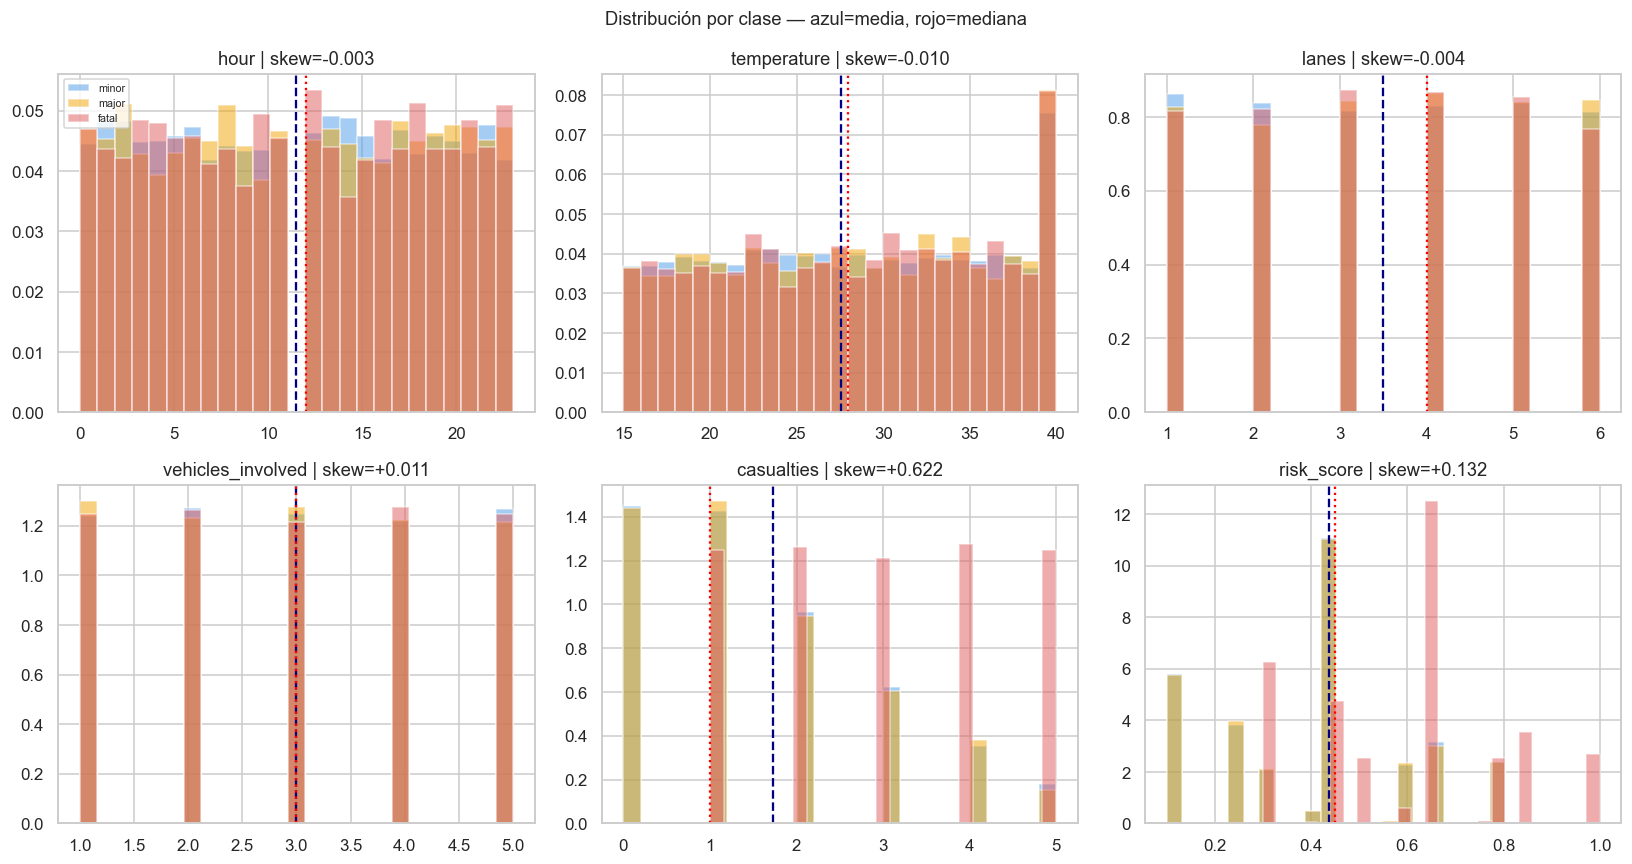

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, var in enumerate(NUM_VARS):
    for clase, color in PALETTE.items():
        axes[i].hist(df[df['accident_severity']==clase][var],
                     bins=25, alpha=0.5, color=color, label=clase, density=True)
    axes[i].axvline(df[var].mean(),   color='navy', linestyle='--', lw=1.5)
    axes[i].axvline(df[var].median(), color='red',  linestyle=':',  lw=1.5)
    axes[i].set_title(f'{var} | skew={skew(df[var]):+.3f}')
    if i == 0: axes[i].legend(fontsize=7)
plt.suptitle('Distribución por clase — azul=media, rojo=mediana', fontsize=12)
plt.tight_layout()
guardar('distribucion_numericas.png')
plt.show()


Se grafican histogramas de cada variable numérica, separados por color según si el accidente fue leve, grave o fatal. Esto permite ver si alguna variable separa bien las clases.

---
## 2.11 Mapa de correlación

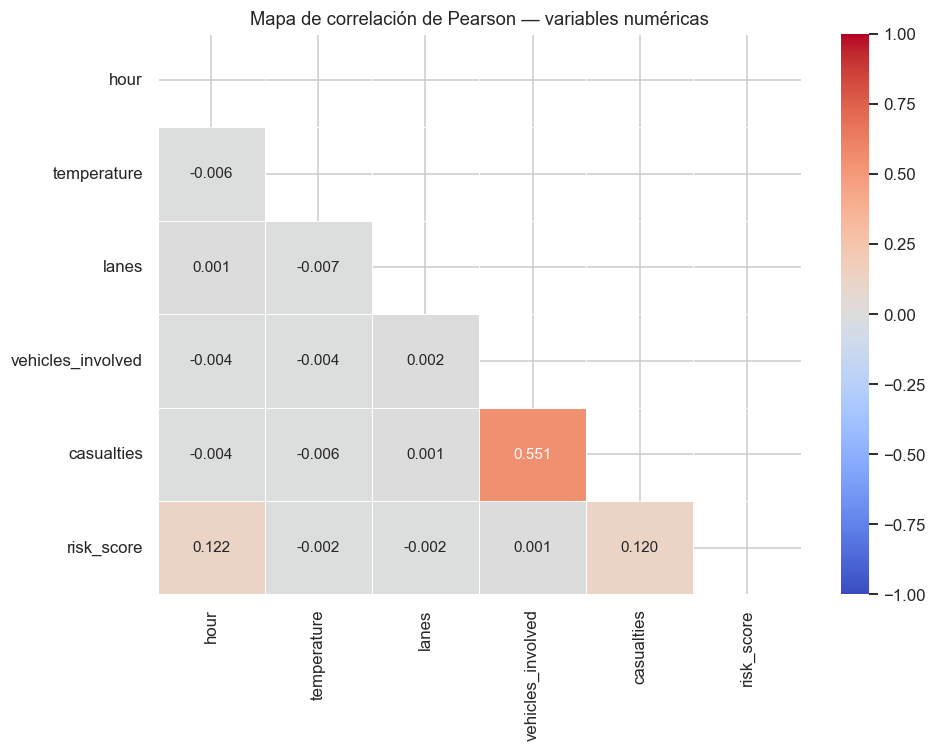

Variable 1,Variable 2,r,Fuerza
vehicles_involved,casualties,0.551000,Moderada


In [22]:
corr = df[NUM_VARS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 10})
ax.set_title('Mapa de correlación de Pearson — variables numéricas')
plt.tight_layout()
guardar('correlacion.png')
plt.show()

pares = []
for i in range(len(NUM_VARS)):
    for j in range(i+1, len(NUM_VARS)):
        v = corr.iloc[i,j]
        if abs(v) > 0.3:
            fuerza = 'Fuerte' if abs(v)>0.7 else 'Moderada'
            pares.append({'Variable 1':NUM_VARS[i], 'Variable 2':NUM_VARS[j],
                          'r':round(v,4), 'Fuerza':fuerza})
if pares:
    display(pd.DataFrame(pares).style
            .set_caption('Pares con correlación notable (|r| > 0.3)').hide(axis='index'))
else:
    display(pd.DataFrame([{'Resultado':'Ningún par supera |r|=0.3 — variables independientes'}])
            .style.hide(axis='index'))


Se construye un mapa de calor de correlaciones de Pearson. El hallazgo más relevante es que `vehicles_involved` y `casualties` tienen una correlación moderada (r=0.55), lo cual tiene sentido ya que entre más vehículos involucrados más víctimas. Sin embargo, se decide mantener ambas variables.

---
## 2.12 Variables categóricas vs target — Chi-cuadrado y V de Cramér

In [23]:
rows_chi = []
for c in CAT_VARS:
    tabla = pd.crosstab(df[c], df['accident_severity'])
    chi2, p, dof, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape)-1)))
    fuerza = 'Fuerte' if v>0.3 else 'Moderada' if v>0.1 else 'Débil/Nula'
    sig = 'Asociación ' if p<0.05 else 'Independiente'
    rows_chi.append({'Variable':c, 'Chi²':round(chi2,2), 'p-valor':round(p,4),
                     'V de Cramér':round(v,4), 'Fuerza':fuerza, 'Conclusión':sig})

display(pd.DataFrame(rows_chi).style
        .set_caption('Chi-cuadrado — H₀: variable independiente del target | V Cramér: 0-0.1=Débil | 0.1-0.3=Moderada | >0.3=Fuerte')
        .hide(axis='index'))


Variable,Chi²,p-valor,V de Cramér,Fuerza,Conclusión
road_type,2.450000,0.654000,0.007800,Débil/Nula,Independiente
weather,0.270000,0.991900,0.002600,Débil/Nula,Independiente
visibility,0.660000,0.955800,0.004100,Débil/Nula,Independiente
traffic_density,1.500000,0.826900,0.006100,Débil/Nula,Independiente
cause,10.810000,0.212800,0.016400,Débil/Nula,Independiente
day_of_week,8.150000,0.773700,0.014300,Débil/Nula,Independiente


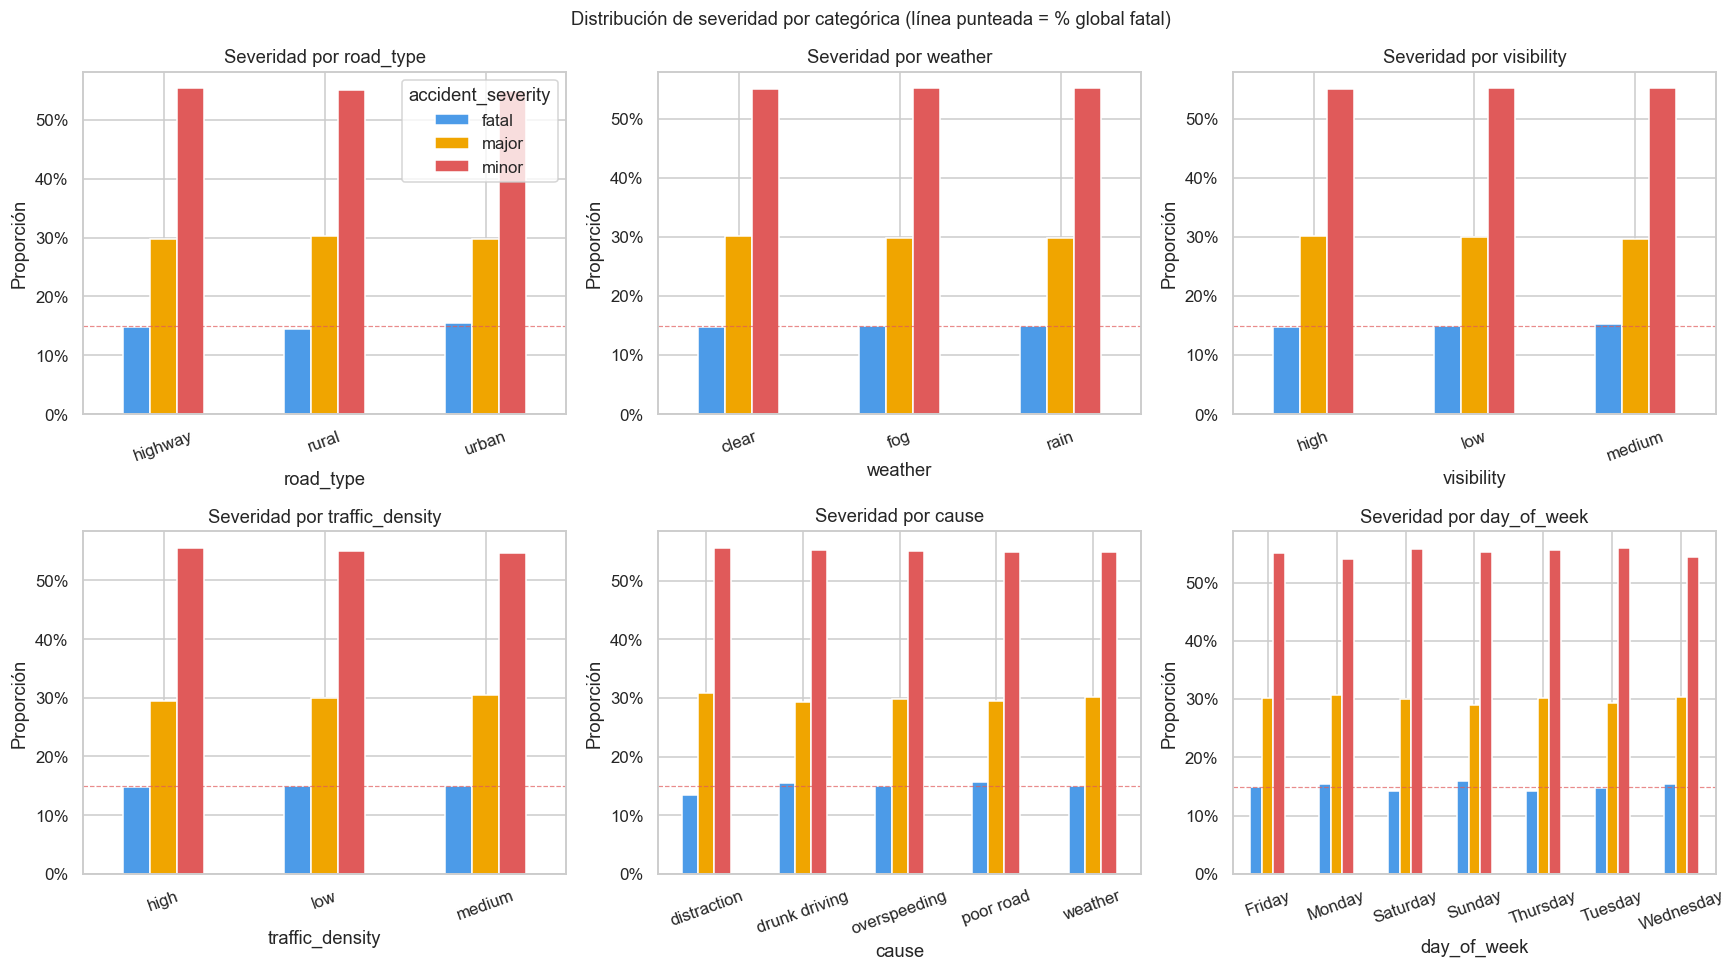

In [24]:
prop_fatal_global = (df['accident_severity']=='fatal').mean()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, var in enumerate(CAT_VARS):
    t = df.groupby(var)['accident_severity'].value_counts(normalize=True).unstack()
    t.plot(kind='bar', ax=axes[i], color=COLORS, edgecolor='white', rot=20, legend=(i==0))
    axes[i].set_title(f'Severidad por {var}')
    axes[i].set_ylabel('Proporción')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[i].axhline(prop_fatal_global, color='#E05A5A', linestyle='--', lw=0.8, alpha=0.7)
plt.suptitle('Distribución de severidad por categórica (línea punteada = % global fatal)', fontsize=12)
plt.tight_layout()
guardar('categoricas_vs_target.png')
plt.show()


Se aplica la prueba estadística Chi-cuadrado para ver si hay asociación entre cada variable categórica y la severidad del accidente. También se calcula la V de Cramér para medir la fuerza de esa asociación. Con esto se obtuvo que ninguna variable categórica tiene asociación significativa con la severidad (todas con p > 0.05, V Cramér ≈ 0). Las proporciones de accidentes leves/graves/fatales son prácticamente iguales en todas las categorías. Esto confirma una vez mas que el dataset es sintético.

---
## 2.13 Análisis temporal — Hora y día

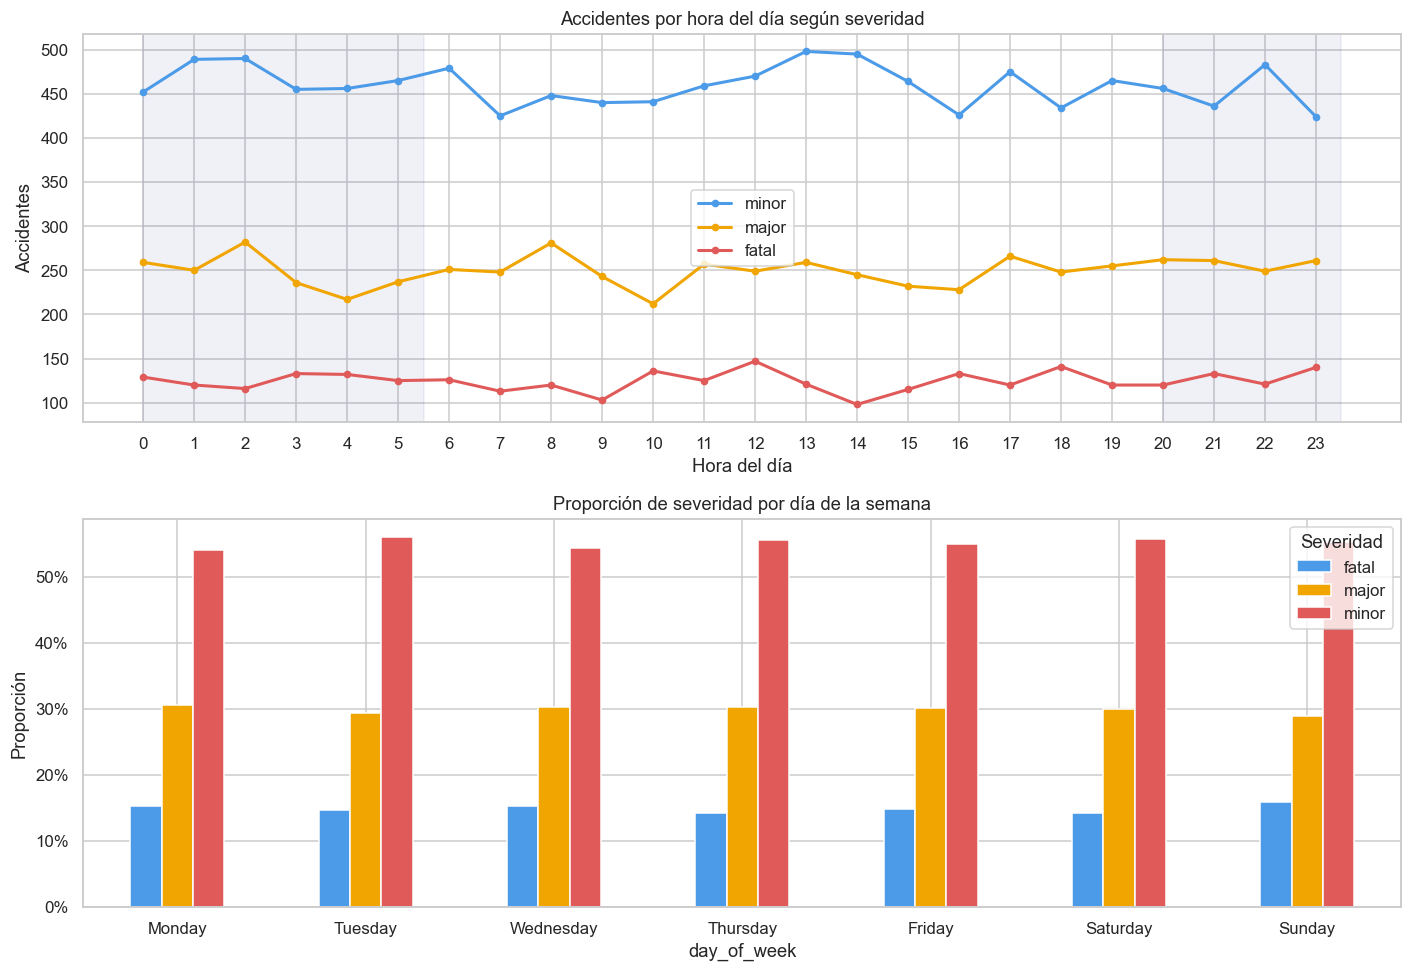

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for clase, color in PALETTE.items():
    ch = df[df['accident_severity']==clase].groupby('hour').size()
    axes[0].plot(ch.index, ch.values, marker='o', label=clase,
                 color=color, linewidth=2, markersize=4)
axes[0].set_xlabel('Hora del día'); axes[0].set_ylabel('Accidentes')
axes[0].set_title('Accidentes por hora del día según severidad')
axes[0].set_xticks(range(0, 24)); axes[0].legend()
axes[0].axvspan(20, 23.5, alpha=0.06, color='navy')
axes[0].axvspan(0, 5.5, alpha=0.06, color='navy')

orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tabla_dia  = (df.groupby('day_of_week')['accident_severity']
                .value_counts(normalize=True).unstack().reindex(orden_dias))
tabla_dia.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='white', rot=0)
axes[1].set_title('Proporción de severidad por día de la semana')
axes[1].set_ylabel('Proporción')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(title='Severidad')
plt.tight_layout()
guardar('accidentes_por_hora.png')
plt.show()


Se analiza cuántos accidentes ocurren por hora del día y por día de la semana, desglosados por severidad. Se generan gráficas de líneas y barras para detectar patrones temporales.

---
## 2.14 Análisis de interacciones

In [26]:
p1 = df.pivot_table(values='accident_severity', index='weather',
                    columns='visibility',
                    aggfunc=lambda x: (x=='fatal').mean()).round(4)
p2 = df.pivot_table(values='accident_severity', index='traffic_density',
                    columns='road_type',
                    aggfunc=lambda x: (x=='fatal').mean()).round(4)

prop_global = round((df['accident_severity']=='fatal').mean(), 4)
display(p1.style.format('{:.3f}')
        .set_caption(f'% Fatal: weather × visibility — Proporción global: {prop_global}'))
display(p2.style.format('{:.3f}')
        .set_caption(f'% Fatal: traffic_density × road_type — Proporción global: {prop_global}'))


visibility,high,low,medium
weather,,,
clear,0.148,nan,nan
fog,nan,0.150,nan
rain,nan,0.146,0.153


road_type,highway,rural,urban
traffic_density,,,
high,0.148,0.143,0.155
low,0.156,0.147,0.147
medium,0.140,0.146,0.162


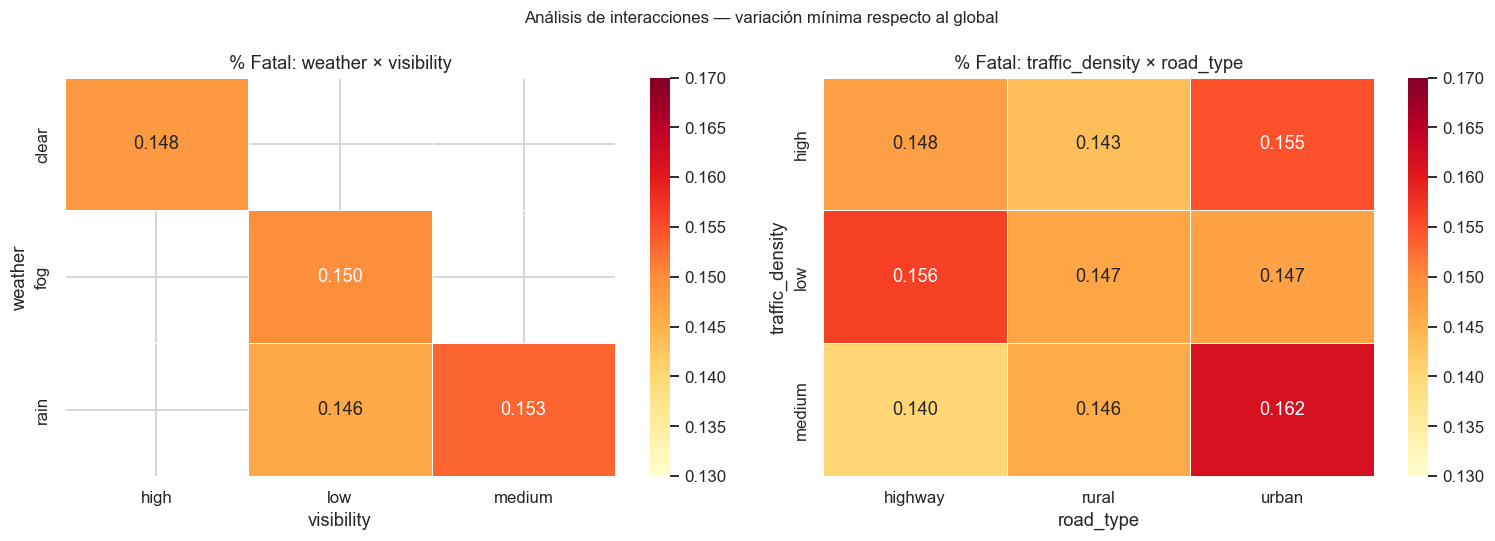

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(p1, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5, vmin=0.13, vmax=0.17)
axes[0].set_title('% Fatal: weather × visibility')
sns.heatmap(p2, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, vmin=0.13, vmax=0.17)
axes[1].set_title('% Fatal: traffic_density × road_type')
plt.suptitle('Análisis de interacciones — variación mínima respecto al global', fontsize=11)
plt.tight_layout()
guardar('interacciones_variables.png')
plt.show()


Se exploran combinaciones de dos variables categóricas (por ejemplo, clima + visibilidad) para ver si juntas tienen mayor poder explicativo sobre la severidad fatal. Las tablas y mapas de calor muestran que las proporciones son prácticamente idénticas en todas las combinaciones y no tienen un impacto significativo en la severidad del accidente, lo que refuerza la conclusión de que el dataset no tiene señal contextual real.

---
## 2.15 `risk_score` — Análisis y evidencia de leakage

In [28]:
display(df.groupby('accident_severity')['risk_score']
        .agg(Media='mean', Mediana='median', Std='std', Mínimo='min', Máximo='max')
        .round(3).style
        .set_caption('risk_score por clase de severidad')
        .background_gradient(cmap='YlOrRd', subset=['Media']))


,Media,Mediana,Std,Mínimo,Máximo
accident_severity,,,,,
fatal,0.608000,0.650000,0.204000,0.300000,1.000000
major,0.407000,0.450000,0.206000,0.100000,0.900000
minor,0.408000,0.450000,0.207000,0.100000,0.900000


In [29]:
# Verificar componente de leakage
df_tmp = df.copy()
df_tmp['rs_base'] = (
    0.10
    + df['weather'].isin(['fog','rain']).astype(int) * 0.15
    + (df['visibility']=='low').astype(int)           * 0.20
    + (df['traffic_density']=='high').astype(int)     * 0.20
    + df['is_peak_hour'] * 0.15
)
df_tmp['diff'] = (df_tmp['risk_score'] - df_tmp['rs_base']).round(2)

n_fatal_leak = ((df_tmp['diff']==0.2) & (df_tmp['accident_severity']=='fatal')).sum()
total_fatal  = (df_tmp['accident_severity']=='fatal').sum()

display(pd.DataFrame([{
    'Hallazgo': 'DATA LEAKAGE DOCUMENTADO',
    'Fatales con diff=+0.20': f'{n_fatal_leak} de {total_fatal}',
    'Porcentaje': f'{n_fatal_leak/total_fatal*100:.1f}%',
    'Decisión': 'Usar risk_score del CSV — nunca ingresado manualmente'
}]).style.set_caption('Evidencia del leakage en risk_score').hide(axis='index'))


Hallazgo,Fatales con diff=+0.20,Porcentaje,Decisión
DATA LEAKAGE DOCUMENTADO,2966 de 2987,99.3%,Usar risk_score del CSV — nunca ingresado manualmente


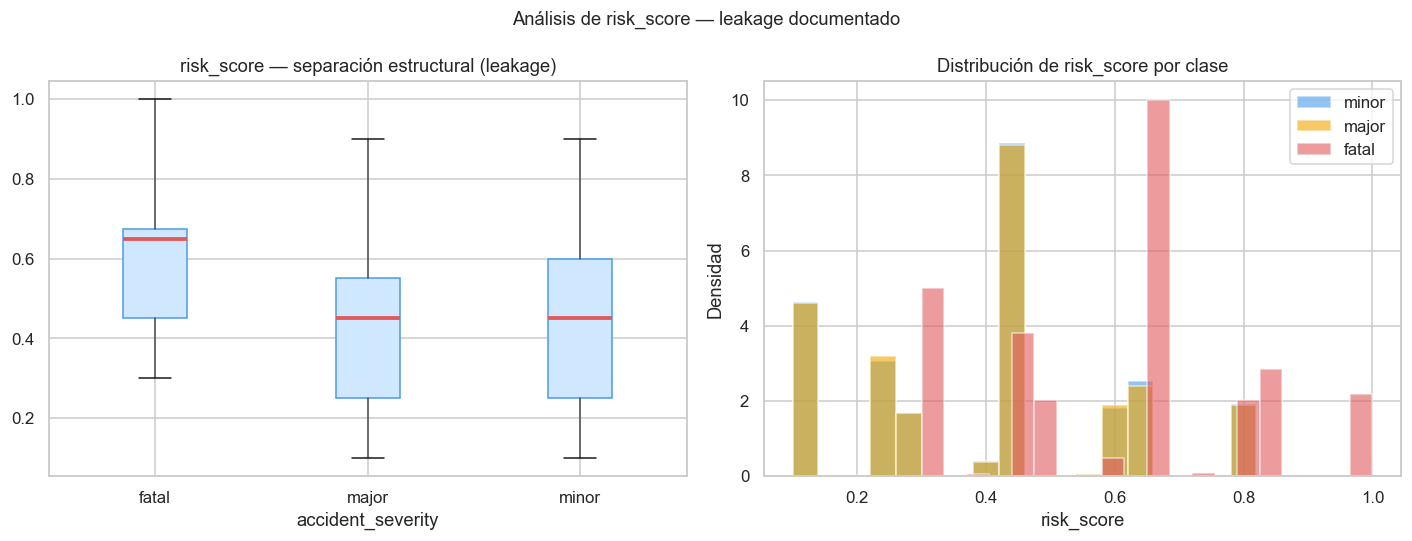

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.boxplot(column='risk_score', by='accident_severity', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#D0E8FF', color='#4C9BE8'),
           medianprops=dict(color='#E05A5A', linewidth=2.5))
axes[0].set_title('risk_score por clase'); axes[0].set_xlabel('accident_severity')
plt.sca(axes[0]); plt.title('risk_score — separación estructural (leakage)')
for clase, color in PALETTE.items():
    axes[1].hist(df[df['accident_severity']==clase]['risk_score'],
                 bins=20, alpha=0.6, color=color, label=clase, density=True)
axes[1].set_xlabel('risk_score'); axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de risk_score por clase'); axes[1].legend()
plt.suptitle('Análisis de risk_score — leakage documentado', fontsize=12)
plt.tight_layout()
guardar('boxplot_risk_score.png')
plt.show()


 Se descubre que la variable `risk_score` contiene data leakage: en el 99.3% de los accidentes fatales, su valor es exactamente 0.20 puntos mayor de lo que sería si solo dependiera de las otras variables. Esto significa que `risk_score` del CVS fue construido usando información de la severidad del accidente.Tener presente que parte del poder predictivo del modelo vendrá de esta variable.

---
## 2.16 Resumen de hallazgos

| Análisis | Hallazgo | Decisión en preparación |
|----------|----------|-------------------------|
| Duplicados | 0 | Sin acción |
| Nulos | `festival` 99.4% | Imputar como `'none'` |
| Outliers (IQR + Z-Score) | 0 en todas las variables | Sin eliminación |
| Asimetría | Ninguna variable con \|skew\|>1 | Sin transformación |
| Normalidad | Ninguna variable normal (3 pruebas) | Sin impacto — modelos no lo requieren |
| Distribución | hour/temp/lanes/vehicles → Uniforme; casualties/risk_score → Gamma | Informativo |
| Transformaciones | Original es mejor o igual para todas | Sin transformación |
| Correlación | vehicles_involved ↔ casualties r=0.55 | Se mantienen ambas |
| Chi² categóricas | Ninguna significativa (p>0.05, V≈0) | Señal solo a través de risk_score |
| Interacciones | Sin variación entre combinaciones | Dataset sin señal contextual real |
| `risk_score` | Leakage +0.20 en 99.3% de fatales | Del CSV, documentado |
| Desbalance | Ratio 3.7x | `class_weight='balanced'` |


En resumen, este notebook hace un analisis completo del dataset antes de modelar: verifica su calidad, entiende sus variables, detecta problemas como el leakage y documenta decisiones concretas para la siguiente etapa.